In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [15]:
samples = torch.load("samples.pt").numpy()
np.random.seed(0)
np.random.shuffle(samples)

In [16]:
QUBITS_MAPPING = {
    0: 4,
    1: 2,
    2: 1,
    3: 7,
    4: 5,
    5: 0,
    6: 8,
    7: 6,
    8: 3,
}
def plot_image_grid(image_list: np.array,
                    rows: int=6,
                    cols: int=5,
                    figsize: tuple=(5, 7),
                    title: dict = None,
                    filename: str = "samples.png"
                    ):
    """
    plot image grid
    """
    samples = image_list[:cols * rows]
    samples_to_plot = []
    for sample in samples:
        sample_to_plot = []
        for i in range(9):
            sample_to_plot.append(sample[QUBITS_MAPPING[i]])
        samples_to_plot.append(np.array(sample_to_plot).reshape(3, 3))
    # print(samples_to_plot.shape)
    samples_to_plot = np.transpose(samples_to_plot, axes=(0, 2, 1))
    assert len(samples_to_plot) > 0, "Received empty image list."
    if title is None:
        title = {}
        title['text'] = f"{len(samples_to_plot)} base image({rows}x{cols} grid)"
        title['fontsize'] = 12
        title['y'] = 0.99
    if len(title) == 0:
        title = {}
        title['text'] = ""
        title['fontsize'] = 12
        title['y'] = 0.99
    if type(title) is str:
        temp = title
        title = {}
        title['text'] = temp
        title['fontsize'] = 12
        title['y'] = 1
    fig, axes = plt.subplots(rows, cols, figsize=figsize) 
    # fig.suptitle(title['text'], fontsize=title['fontsize'], y=title['y']) 
    for index, single_image_data in enumerate(samples_to_plot):
        if index >= rows * cols: 
            break
        row_idx = index // cols
        col_idx = index % cols       
        ax = axes[row_idx, col_idx]
        img_array = np.array(single_image_data)
        ax.imshow(img_array, cmap='binary', vmin=0, vmax=1) 
        ax.set_xticks([])  
        ax.set_yticks([])  
    for i in range(len(samples_to_plot), rows * cols):
        row_idx = i // cols
        col_idx = i % cols
        if rows > 1 or cols > 1 : 
            fig.delaxes(axes[row_idx,col_idx])
        else: 
            fig.delaxes(axes[i])
    plt.tight_layout(rect=[0, 0, 1, 1]) # 调整布局以适应主标题
    plt.savefig(filename, dpi=300)
    plt.show()

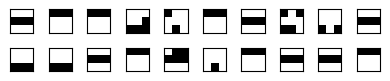

In [31]:
plot_image_grid(samples, rows=2, cols=10, figsize=(4,1),title="", filename="samples.pdf")

In [3]:
probs = torch.load('probs.pt')
probs

tensor([0.0054, 0.0012, 0.0015, 0.0078, 0.0022, 0.0007, 0.0005, 0.0002, 0.0005,
        0.0007, 0.0000, 0.0020, 0.0168, 0.0005, 0.0005, 0.0002, 0.0002, 0.0029,
        0.0061, 0.2393, 0.0012, 0.0000, 0.0002, 0.0037, 0.0002, 0.0010, 0.0002,
        0.0068, 0.0027, 0.0000, 0.0000, 0.0005, 0.0020, 0.0002, 0.0002, 0.0000,
        0.0000, 0.0000, 0.0002, 0.0007, 0.0002, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0015, 0.0002, 0.0000, 0.0024, 0.0002, 0.0002,
        0.0002, 0.0002, 0.0002, 0.0000, 0.0002, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0002, 0.0012, 0.0000, 0.0000, 0.0027, 0.0076, 0.0002, 0.0007, 0.0002,
        0.0034, 0.0002, 0.0002, 0.0010, 0.2246, 0.0044, 0.0017, 0.0005, 0.0002,
        0.0002, 0.0002, 0.0117, 0.0034, 0.0002, 0.0010, 0.0007, 0.0000, 0.0002,
        0.0010, 0.0039, 0.0059, 0.0002, 0.0005, 0.0049, 0.0002, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0005, 0.0000, 0.0002, 0.0000, 0.0002,
        0.0010, 0.0005, 0.0000, 0.0007, 

In [4]:
def get_transformed_probs(old_probs):
    """
    Apply (Mapping -> Reshape -> Transpose) logic to the full probability vector.
    """
    old_probs = np.array(old_probs)
    new_probs = np.zeros_like(old_probs)
    
    # 遍历所有可能的 512 个状态
    for old_idx in range(len(old_probs)):
        prob = old_probs[old_idx]
        
        # 如果概率为0，跳过以节省时间（稀疏优化）
        if prob < 1e-10:
            continue
            
        # 1. 将整数索引转换为 9位 比特数组 (Old State)
        # 例如: 256 -> [1, 0, 0, 0, 0, 0, 0, 0, 0]
        # 注意：这里假设你的 idx 转换是 Big-Endian (q0在左) 也就是和你 sample[i] 是一致的
        old_bits = np.array([int(x) for x in format(old_idx, '09b')])
        
        # 2. 应用 QUBITS_MAPPING (重排比特)
        # 逻辑：new_sample[i] = old_sample[QUBITS_MAPPING[i]]
        mapped_bits = np.zeros(9, dtype=int)
        for i in range(9):
            mapped_bits[i] = old_bits[QUBITS_MAPPING[i]]
            
        # 3. Reshape (3x3) & Transpose (T)
        # 你的逻辑：reshape(3,3) 然后 transpose(0, 2, 1) 其实就是矩阵转置
        grid = mapped_bits.reshape(3, 3)
        grid_T = grid.T  # Transpose
        
        # 4. Flatten 变回一维
        final_bits = grid_T.flatten()
        
        # 5. 将比特数组转回整数索引 (New Index)
        # [1, 0, ...] -> int
        final_bitstring = "".join(str(b) for b in final_bits)
        new_idx = int(final_bitstring, 2)
        
        # 6. 填入新的概率数组
        new_probs[new_idx] = prob
        
    return torch.tensor(new_probs)

# 使用示例：
# 假设 raw_probs 是你从 IBM 或模拟器拿到的原始 512 维向量
transformed_probs = get_transformed_probs(probs)

/tmp/ipykernel_1146051/2856782147.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  old_probs = np.array(old_probs)


In [5]:
torch.topk(probs, k=4), torch.topk(transformed_probs, k=4)

(torch.return_types.topk(
 values=tensor([0.2393, 0.2246, 0.2092, 0.0208], dtype=torch.float64),
 indices=tensor([ 19,  76, 416, 384])),
 torch.return_types.topk(
 values=tensor([0.2393, 0.2246, 0.2092, 0.0208], dtype=torch.float64),
 indices=tensor([448,  56,   7,   6])))

In [6]:
isotns_probs = 0 * probs
isotns_probs[448]=isotns_probs[56]=isotns_probs[7]=1/3

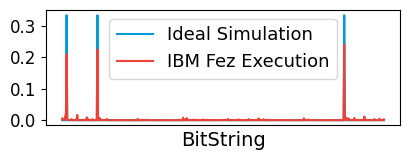

In [34]:
x = np.arange(len(transformed_probs)) # 0 到 511
plt.figure(figsize=(4.2, 1.7))
plt.plot(x, isotns_probs, label='Ideal Simulation', color='#009ad6')
plt.plot(x, transformed_probs, label='IBM Fez Execution', color='#ef4136')
plt.xticks([])
plt.xlabel('BitString', fontsize=14)
plt.yticks([0, 0.1, 0.2, 0.3], fontsize=12)
plt.legend(fontsize=13, loc='upper center')
plt.tight_layout()
plt.savefig('three_patterns.pdf', dpi=300)